## Weather Data EDA

In [9]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

conn = duckdb.connect("../monza_f1_data.duckdb")

query = """
    SELECT 
        *
    FROM weather
    JOIN session USING (session_key)
    ORDER BY date
"""

weather_df = conn.execute(query).df()

conn.close()

weather_df.head(10)

,date,session_key,pressure,track_temperature,rainfall,wind_speed,meeting_key,wind_direction,humidity,air_temperature,...,date_end,meeting_key_1,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year
0,2023-09-01T11:15:25.883000+00:00,9150,997.7,40.8,0,2.0,1218,153,50.0,24.9,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
1,2023-09-01T11:16:25.898000+00:00,9150,997.7,40.8,0,1.7,1218,248,50.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
2,2023-09-01T11:17:25.897000+00:00,9150,997.5,40.8,0,1.3,1218,276,51.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
3,2023-09-01T11:18:25.896000+00:00,9150,997.7,40.5,0,0.6,1218,0,50.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
4,2023-09-01T11:19:25.895000+00:00,9150,997.7,40.5,0,1.3,1218,146,51.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
5,2023-09-01T11:20:25.893000+00:00,9150,997.7,40.8,0,1.7,1218,225,50.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
6,2023-09-01T11:21:25.908000+00:00,9150,997.7,41.2,0,0.6,1218,207,49.0,25.1,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
7,2023-09-01T11:22:25.907000+00:00,9150,997.5,39.7,0,1.1,1218,152,49.0,25.1,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
8,2023-09-01T11:23:25.906000+00:00,9150,997.7,38.8,0,1.2,1218,180,48.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023
9,2023-09-01T11:24:25.905000+00:00,9150,997.5,38.2,0,1.2,1218,180,49.0,25.0,...,2023-09-01T12:30:00+00:00,1218,39,Monza,13,ITA,Italy,Monza,02:00:00,2023


### Monza track temperature senaste åren

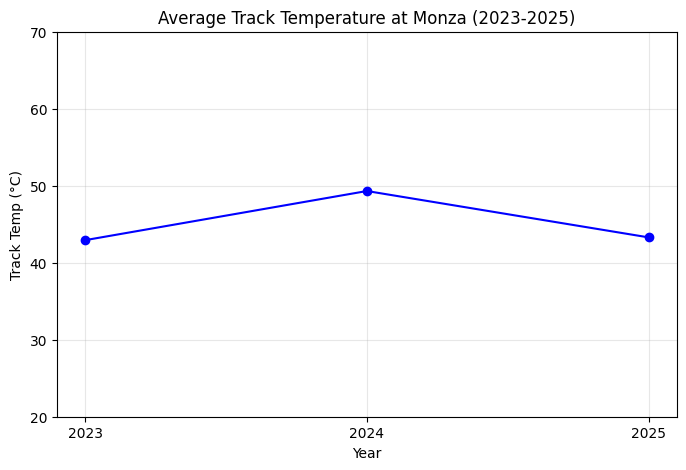

In [10]:
race_temperature_3_years = weather_df[
    (weather_df['session_name'] == 'Race') &
    (weather_df['year'].isin([2023, 2024, 2025]))
]

avg_track_temperature_monza = race_temperature_3_years.groupby('year')['track_temperature'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

avg_track_temperature_monza.plot(kind='line', color='blue', marker='o', ax=ax)

ax.set_title('Average Track Temperature at Monza (2023-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Track Temp (°C)')
ax.set_ylim(20, 70)
ax.set_xticks([2023, 2024, 2025])


plt.grid(True, alpha=0.3)

plt.show()

In [11]:
# Find out average rainfall on monza during all sessions in 2023, 2024, and 2025
rainfall_monza = weather_df[weather_df['year'].isin([2023, 2024, 2025])]

avg_rainfall_monza = rainfall_monza.groupby(['year', 'session_name'])['rainfall'].mean().reset_index()

print(avg_rainfall_monza)

    year session_name  rainfall
0   2023   Practice 1       0.0
1   2023   Practice 2       0.0
2   2023   Practice 3       0.0
3   2023   Qualifying       0.0
4   2023         Race       0.0
5   2024   Practice 1       0.0
6   2024   Practice 2       0.0
7   2024   Practice 3       0.0
8   2024   Qualifying       0.0
9   2024         Race       0.0
10  2025   Practice 1       0.0
11  2025   Practice 2       0.0
12  2025   Practice 3       0.0
13  2025   Qualifying       0.0
14  2025         Race       0.0


### Vind riktning från Monza Race 2023-2025

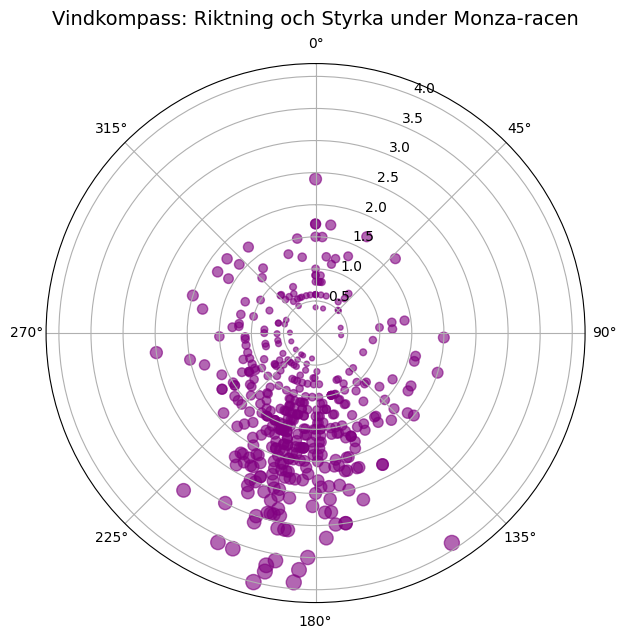

In [ ]:

race_wind_monza = weather_df[(weather_df['session_name'] == 'Race')] 

#https://matplotlib.org/stable/gallery/pie_and_polar_charts/polar_demo.html
angles_rad = np.radians(race_wind_monza['wind_direction'])

# bygga en rund graf, "polar"
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})

# Sätt norr (0 grader) högst upp och vinklarna går medurs
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1) 

# Scatter värden: Ju starkare wind_speed desto större prickar
scatter = ax.scatter(angles_rad, race_wind_monza['wind_speed'], alpha=0.6, color='purple', s=race_wind_monza['wind_speed']*30)

ax.set_title('Vindkompass: Riktning och Styrka under Monza-racen', va='bottom', fontsize=14)

plt.show()

In [ ]:
weather_df.to_csv('../data/csv/monza_weather_data.csv', index=False)
avg_track_temperature_monza.to_csv('../data/csv/avg_track_temperature_monza.csv', index=True)
avg_rainfall_monza.to_csv('../data/csv/avg_rainfall_monza.csv', index=False)